# Chapter 10: Vector Bundles

## Source Span

**Book.** `Introduction to Smooth Manifolds`

**Chapter.** Chapter 10, `Vector Bundles`

**Printed pages.** `249-271` in the course `source_map.json`

**PDF pages inspected.** physical pages `267-289`, because the PDF front matter shifts printed page numbers by 18.

**Source-map focus.** Vector bundles, sections, bundle homomorphisms, subbundles, and fiber bundles.

This notebook uses the source for orientation, terminology, and coverage only. The examples, prose, diagrams, checks, and lab prompts below are original teaching material.

## Chapter Goal

A vector bundle is a family of vector spaces that becomes a product only after looking locally. The chapter's recurring test is: **which data are fiberwise linear, which data are only topological or smooth, and which local choices glue consistently on overlaps?**

By the end of the notebook you should be able to inspect:

- a local trivialization as a coordinate system for fibers;
- a transition function as the visible record of twisting;
- a section as a point in each fiber, with zero/nonzero behavior tied to global triviality;
- a local frame as a trivialization written in section language;
- a bundle homomorphism as a pointwise, `C^infty(M)`-linear operation on sections;
- a subbundle as a constant-rank family of subspaces detected by local frames;
- a fiber bundle as local product data without the extra vector-space requirements.


## Visual Storyboard

| Step | Concept | Representation | Artifact | What to inspect | Check |
| --- | --- | --- | --- | --- | --- |
| 1 | source dependency map | directed graph | `chapter10-concept-dependency-map.png` | how definitions feed constructions and failure tests | graph connectivity and named source concepts |
| 2 | vector bundle and local trivialization | product cylinder beside a Mobius line bundle | `local-products-and-mobius-twist.png` | every small arc looks like `U x R`, while the global return can flip fiber orientation | endpoint fiber directions have dot products `+1` and `-1` |
| 3 | transition functions | overlap-sign diagram for a two-chart line bundle | `transition-functions-mobius-cocycle.png` | twisting lives on overlaps, not in a single chart | transition values lie in `GL(1,R)` and inverse products equal `1` |
| 4 | sections and frames | product section versus Mobius section | `sections-global-frame-obstruction.png` | a nonzero global line-bundle section is a global frame; the Mobius endpoint rule forces a zero | anti-periodic endpoint relation and zero detection |
| 5 | tangent/cotangent-style examples | local frame and dual coframe on a sphere patch | `tangent-cotangent-local-frame.png` | tangent vectors span fibers; covectors are dual tests on those fibers | dual-pairing matrix is the identity |
| 6 | bundle homomorphisms | rank tracker for pointwise matrix maps | `bundle-homomorphism-rank-tracker.png` | constant rank gives stable kernel/image bundles; rank drops break subbundle status | rank set and `C^infty`-linearity residuals |
| 7 | subbundles and normal bundles | tangent/normal line subbundles on a circle plus a rank-drop failure | `subbundle-normal-rank-test.png` | local frames certify subbundles; a vanishing generator does not | orthogonality, unit length, and radial zero check |
| 8 | fiber bundles | two-sheet covering and Mobius interval bundle | `fiber-bundle-models.png` | local products need not carry vector-space operations | two preimages per base point and interval addition counterexample |


## Library Routing

| Concept | Representation | Library | Why this route fits | Fallback |
| --- | --- | --- | --- | --- |
| dependency and proof flow | directed graph | `NetworkX` + `Matplotlib` | the chapter is definition-heavy, so a graph shows which notions support later tests | markdown table only |
| product and Mobius line bundles | low-dimensional surfaces and fibers | `Matplotlib` 3D | the examples are small enough to inspect without a mesh engine | 2D strip diagrams |
| transition functions and cocycles | sign functions, overlap graph | `SymPy`, `NetworkX`, `Matplotlib` | `GL(1,R)` checks are exact, and disconnected overlaps are graph-like | numeric sign table |
| sections, frames, local trivializations | curves and endpoint rules | `NumPy`, `Matplotlib` | endpoint and zero behavior is the visible global obstruction | tabular endpoint check |
| tangent/cotangent-style examples | sphere patch, frame arrows, dual-pairing matrix | `NumPy`, `SymPy`, `Matplotlib` | the tangent bundle is central here, and the dual-bundle pattern previews the next chapter | coordinate-only matrix check |
| homomorphisms and subbundles | rank plots, symbolic `C^infty` residuals | `SymPy`, `NumPy`, `Matplotlib` | the constant-rank and pointwise-linearity hypotheses are executable | hand-written rank table |
| fiber bundles | covering and interval-fiber diagrams | `Matplotlib` | arbitrary model fibers are easiest to compare visually in low dimension | text-only examples |

The catalog suggests heavier 3D/mesh tools when curvature or mesh topology is the object of study. Here the chapter's geometry is gluing, rank, and fiberwise linearity, so durable Matplotlib diagrams plus exact symbolic checks are the smallest reliable route.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import networkx as nx
import numpy as np
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Introduction-to-Smooth-Manifolds course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-10-vector-bundles"
UNIT_TITLE = "Vector Bundles"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
HTML = ARTIFACT_ROOT / "html"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
})

def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

def set_3d_equal(ax, radius=1.6):
    ax.set_xlim(-radius, radius)
    ax.set_ylim(-radius, radius)
    ax.set_zlim(-radius, radius)
    try:
        ax.set_box_aspect((1, 1, 0.75))
    except Exception:
        pass

generated_artifacts = []

routing_rows = [
    {"concept": "dependency and proof flow", "representation": "directed graph", "library": "NetworkX + Matplotlib", "artifact_or_check": "chapter10-concept-dependency-map.png"},
    {"concept": "local trivialization", "representation": "product and Mobius line bundle surfaces", "library": "Matplotlib 3D", "artifact_or_check": "local-products-and-mobius-twist.png"},
    {"concept": "transition functions", "representation": "overlap sign diagram", "library": "SymPy + NetworkX + Matplotlib", "artifact_or_check": "transition-functions-mobius-cocycle.png"},
    {"concept": "sections and frames", "representation": "endpoint and zero obstruction", "library": "NumPy + Matplotlib", "artifact_or_check": "sections-global-frame-obstruction.png"},
    {"concept": "tangent and cotangent examples", "representation": "sphere frame and dual pairing", "library": "NumPy + Matplotlib", "artifact_or_check": "tangent-cotangent-local-frame.png"},
    {"concept": "bundle homomorphisms", "representation": "rank tracker and symbolic residuals", "library": "SymPy + NumPy + Matplotlib", "artifact_or_check": "bundle-homomorphism-rank-tracker.png"},
    {"concept": "subbundles", "representation": "local frame criterion plus rank failure", "library": "NumPy + Matplotlib", "artifact_or_check": "subbundle-normal-rank-test.png"},
    {"concept": "fiber bundles", "representation": "covering and interval-fiber models", "library": "Matplotlib", "artifact_or_check": "fiber-bundle-models.png"},
]
routing_path = save_csv(routing_rows, TABLES / "chapter10-library-routing.csv")
generated_artifacts.append(routing_path)

source_inventory = {
    "book": "Introduction to Smooth Manifolds",
    "chapter": "Chapter 10: Vector Bundles",
    "printed_pages": "249-271",
    "pdf_physical_pages_inspected": "267-289",
    "source_map_focus": "Vector bundles, sections, bundle homomorphisms, subbundles, and fiber bundles.",
    "concepts": [
        "vector bundle",
        "local trivialization",
        "transition function",
        "vector bundle chart lemma",
        "Whitney sum",
        "restricted bundle",
        "section",
        "local/global frame",
        "bundle homomorphism",
        "subbundle",
        "constant-rank kernel/image test",
        "normal bundle",
        "fiber bundle",
    ],
}
source_inventory_path = save_json(source_inventory, CHECKS / "source-span-inventory.json")
generated_artifacts.append(source_inventory_path)

print("Book root located from current notebook context")
print(f"Artifacts: {rel(ARTIFACT_ROOT)}")
print(f"Routing table: {rel(routing_path)}")


Book root located from current notebook context
Artifacts: artifacts/chapter-10-vector-bundles
Routing table: artifacts/chapter-10-vector-bundles/tables/chapter10-library-routing.csv


## Translation Guide

| Book language | Computational language used here | What can fail |
| --- | --- | --- |
| total space `E` | a set of all fibers, drawn here as a band, cylinder, or collection of arrows | it may not be globally a product |
| projection `pi:E -> M` | the map that forgets the fiber coordinate | not being a submersion would contradict local product structure |
| fiber `E_p` | one vector space attached to the base point `p` | dimensions must be constant for a vector bundle |
| local trivialization `Phi_U` | coordinates `(p, v)` on `pi^{-1}(U)` | incompatible overlaps can block a smooth bundle |
| transition function `g_UV` | a smooth map from overlaps into `GL(k,R)` | leaving `GL(k,R)` breaks invertible change of frame |
| section `sigma` | a graph choosing one vector in each fiber | global nonzero sections can be obstructed by twisting |
| local frame | several sections forming a basis in every fiber | a vanishing generator is not a frame |
| bundle homomorphism | a pointwise linear map on fibers | differential operators on sections usually fail `C^infty(M)`-linearity |
| subbundle | a constant-rank choice of subspaces | rank jumps produce a family of subspaces, not a subbundle |
| fiber bundle | local product with model fiber `F` | the fiber may not be a vector space |


## Source-Grounded Concept Map

The chapter is not just a list of examples. Its definitions build a pipeline: local trivializations create transition functions; transition functions support the chart lemma; local frames translate trivializations into section language; homomorphisms and constant-rank tests create subbundles; fiber bundles remove the vector-space constraint.


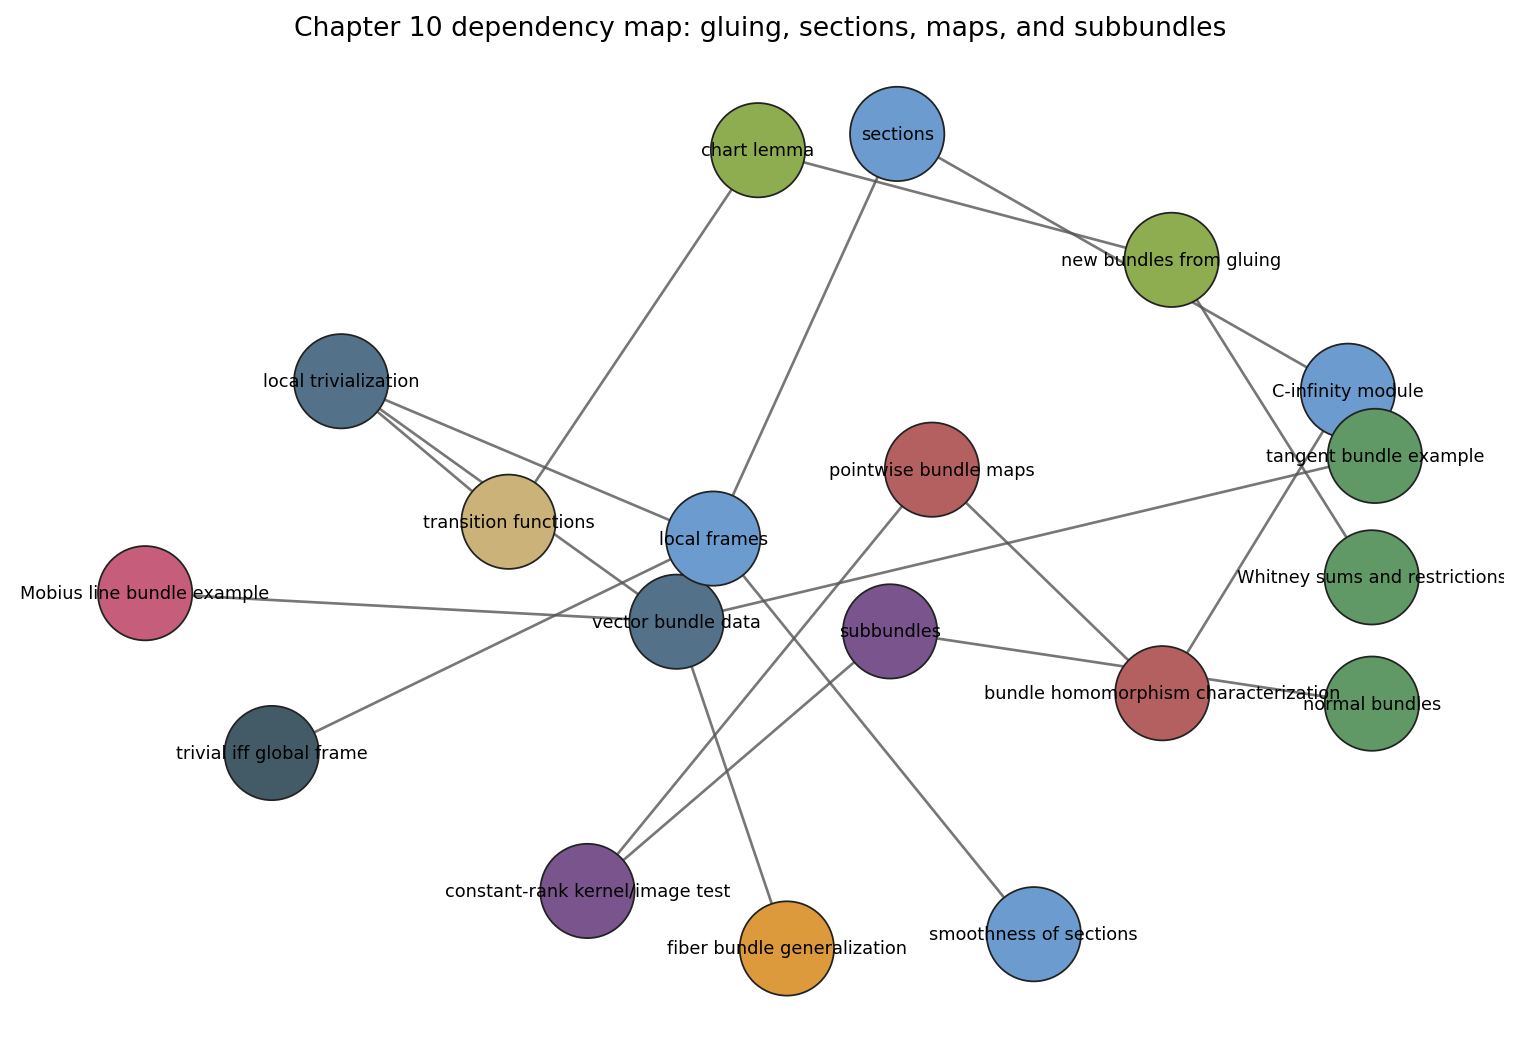

In [2]:
concept_graph = nx.DiGraph()
concept_graph.add_edges_from([
    ("vector bundle data", "local trivialization"),
    ("local trivialization", "transition functions"),
    ("transition functions", "chart lemma"),
    ("chart lemma", "new bundles from gluing"),
    ("new bundles from gluing", "Whitney sums and restrictions"),
    ("local trivialization", "local frames"),
    ("local frames", "sections"),
    ("local frames", "smoothness of sections"),
    ("local frames", "trivial iff global frame"),
    ("sections", "C-infinity module"),
    ("C-infinity module", "bundle homomorphism characterization"),
    ("bundle homomorphism characterization", "pointwise bundle maps"),
    ("pointwise bundle maps", "constant-rank kernel/image test"),
    ("constant-rank kernel/image test", "subbundles"),
    ("subbundles", "normal bundles"),
    ("vector bundle data", "tangent bundle example"),
    ("vector bundle data", "Mobius line bundle example"),
    ("vector bundle data", "fiber bundle generalization"),
])
role = {
    "vector bundle data": "definition",
    "local trivialization": "definition",
    "transition functions": "gluing",
    "chart lemma": "construction",
    "new bundles from gluing": "construction",
    "Whitney sums and restrictions": "example",
    "local frames": "sections",
    "smoothness of sections": "sections",
    "trivial iff global frame": "invariant",
    "sections": "sections",
    "C-infinity module": "sections",
    "bundle homomorphism characterization": "homomorphism",
    "pointwise bundle maps": "homomorphism",
    "constant-rank kernel/image test": "subbundle",
    "subbundles": "subbundle",
    "normal bundles": "example",
    "tangent bundle example": "example",
    "Mobius line bundle example": "failure mode",
    "fiber bundle generalization": "fiber bundle",
}
colors = {
    "definition": "#537188",
    "gluing": "#CBB279",
    "construction": "#8EAC50",
    "sections": "#6C9BCF",
    "homomorphism": "#B46060",
    "subbundle": "#7A548C",
    "example": "#609966",
    "failure mode": "#C65D7B",
    "fiber bundle": "#DD9A3C",
    "invariant": "#435B66",
}
pos = nx.spring_layout(concept_graph, seed=1007, k=1.05)
fig, ax = plt.subplots(figsize=(12, 8))
nx.draw_networkx_edges(concept_graph, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.2, edge_color="#555555", alpha=0.8)
nx.draw_networkx_nodes(
    concept_graph,
    pos,
    ax=ax,
    node_color=[colors[role[n]] for n in concept_graph.nodes],
    node_size=1800,
    linewidths=0.8,
    edgecolors="#222222",
)
nx.draw_networkx_labels(concept_graph, pos, ax=ax, font_size=8)
ax.set_title("Chapter 10 dependency map: gluing, sections, maps, and subbundles")
ax.axis("off")
concept_map_path = save_matplotlib(fig, FIGURES / "chapter10-concept-dependency-map.png")
plt.close(fig)

concept_map_check_path = save_json(
    {
        "nodes": list(concept_graph.nodes),
        "edges": list(concept_graph.edges),
        "weakly_connected": bool(nx.is_weakly_connected(concept_graph)),
        "contains_required_terms": all(
            term in " ".join(concept_graph.nodes).lower()
            for term in ["vector bundle", "transition", "sections", "homomorphism", "subbundles", "fiber bundle"]
        ),
    },
    CHECKS / "chapter10-concept-dependency-map.json",
)
generated_artifacts.extend([concept_map_path, concept_map_check_path])
display_artifact(concept_map_path, width=900)


## Vector Bundles: Local Product, Global Gluing

A product line bundle over `S^1` really is `S^1 x R`: go once around the base and the fiber direction returns to itself. A Mobius line bundle also looks like `U x R` over a short arc `U`, but after one full circuit the same local fiber coordinate has returned with opposite sign.

The key inspection target is not the band itself; it is the **fiber direction along the zero section**. A local trivialization can straighten nearby fibers, but transition functions remember how one straightening compares with another.


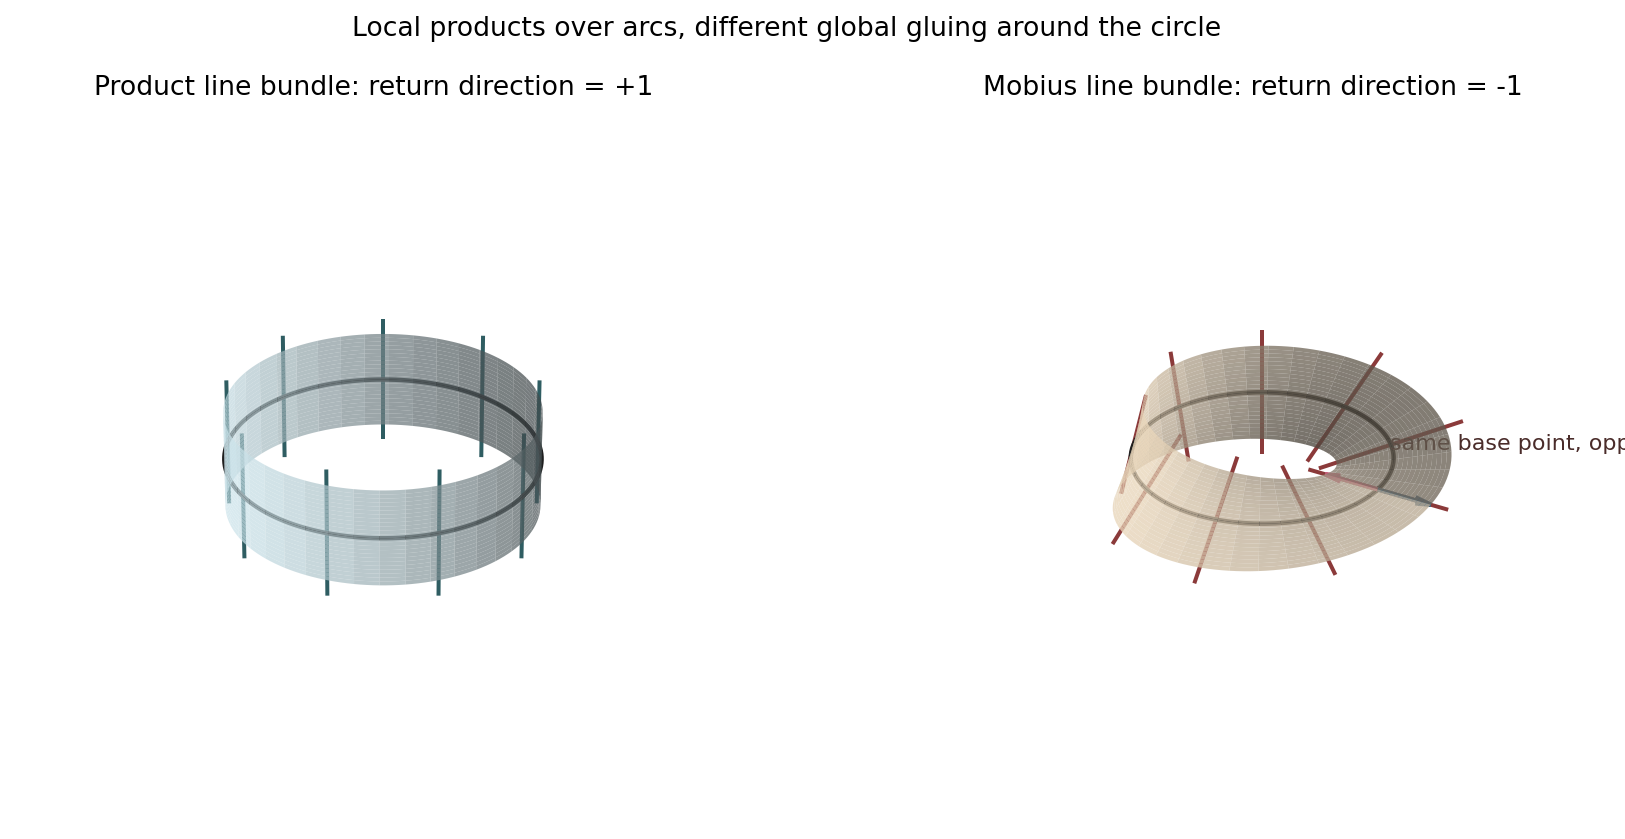

In [3]:
theta = np.linspace(0, 2 * np.pi, 160)
s_vals = np.linspace(-0.45, 0.45, 25)
T, S = np.meshgrid(theta, s_vals)

prod_x = np.cos(T)
prod_y = np.sin(T)
prod_z = S

mob_x = (1 + S * np.cos(T / 2)) * np.cos(T)
mob_y = (1 + S * np.cos(T / 2)) * np.sin(T)
mob_z = S * np.sin(T / 2)

def mobius_direction(angle):
    return np.array([
        np.cos(angle / 2) * np.cos(angle),
        np.cos(angle / 2) * np.sin(angle),
        np.sin(angle / 2),
    ])

fig = plt.figure(figsize=(13, 5.8))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(prod_x, prod_y, prod_z, color="#cfe8ef", alpha=0.72, linewidth=0, antialiased=True)
for angle in np.linspace(0, 2 * np.pi, 9, endpoint=False):
    fiber = np.linspace(-0.58, 0.58, 2)
    ax1.plot(np.cos(angle) * np.ones_like(fiber), np.sin(angle) * np.ones_like(fiber), fiber, color="#2f5d62", linewidth=1.8)
ax1.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), color="#1f1f1f", linewidth=2.0, label="zero section")
ax1.set_title("Product line bundle: return direction = +1")
ax1.set_axis_off()
set_3d_equal(ax1, 1.45)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(mob_x, mob_y, mob_z, color="#ead7bb", alpha=0.78, linewidth=0, antialiased=True)
for angle in np.linspace(0, 2 * np.pi, 9, endpoint=False):
    fiber = np.linspace(-0.58, 0.58, 2)
    direction = mobius_direction(angle)
    base = np.array([np.cos(angle), np.sin(angle), 0.0])
    pts = base[:, None] + direction[:, None] * fiber[None, :]
    ax2.plot(pts[0], pts[1], pts[2], color="#8b3a3a", linewidth=1.8)
ax2.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), color="#1f1f1f", linewidth=2.0, label="zero section")
ax2.quiver(1, 0, 0, *mobius_direction(0), length=0.45, color="#355c7d", linewidth=2)
ax2.quiver(1, 0, 0, *mobius_direction(2 * np.pi), length=0.45, color="#c65d7b", linewidth=2)
ax2.text(1.1, 0, 0.5, "same base point, opposite fiber direction", color="#4a2c2a")
ax2.set_title("Mobius line bundle: return direction = -1")
ax2.set_axis_off()
set_3d_equal(ax2, 1.75)

fig.suptitle("Local products over arcs, different global gluing around the circle", y=0.98)
local_product_path = save_matplotlib(fig, FIGURES / "local-products-and-mobius-twist.png")
plt.close(fig)

product_direction_start = np.array([0.0, 0.0, 1.0])
product_direction_end = np.array([0.0, 0.0, 1.0])
mobius_direction_start = mobius_direction(0)
mobius_direction_end = mobius_direction(2 * np.pi)
local_product_check = {
    "product_endpoint_direction_dot": float(np.dot(product_direction_start, product_direction_end)),
    "mobius_endpoint_direction_dot": float(np.dot(mobius_direction_start, mobius_direction_end)),
    "product_returns_with_same_orientation": bool(np.dot(product_direction_start, product_direction_end) > 0.999),
    "mobius_returns_with_opposite_orientation": bool(np.dot(mobius_direction_start, mobius_direction_end) < -0.999),
}
local_product_check_path = save_json(local_product_check, CHECKS / "local-products-and-mobius-twist.json")
generated_artifacts.extend([local_product_path, local_product_check_path])
display_artifact(local_product_path, width=900)


## Transition Functions: The Overlap Is Where Twisting Lives

A single trivialization hides twisting because it has already chosen fiber coordinates. The transition function compares two such choices on an overlap. For a line bundle the structure group is `GL(1,R)`, so a transition value is just a nonzero real number. The Mobius line bundle can be encoded with two charts whose overlap has two components: one component uses sign `+1`, the other uses sign `-1`.

This is the smallest gluing model that teaches the chapter's vector bundle chart lemma: if the overlap functions are smooth and always invertible, they define a smooth bundle.


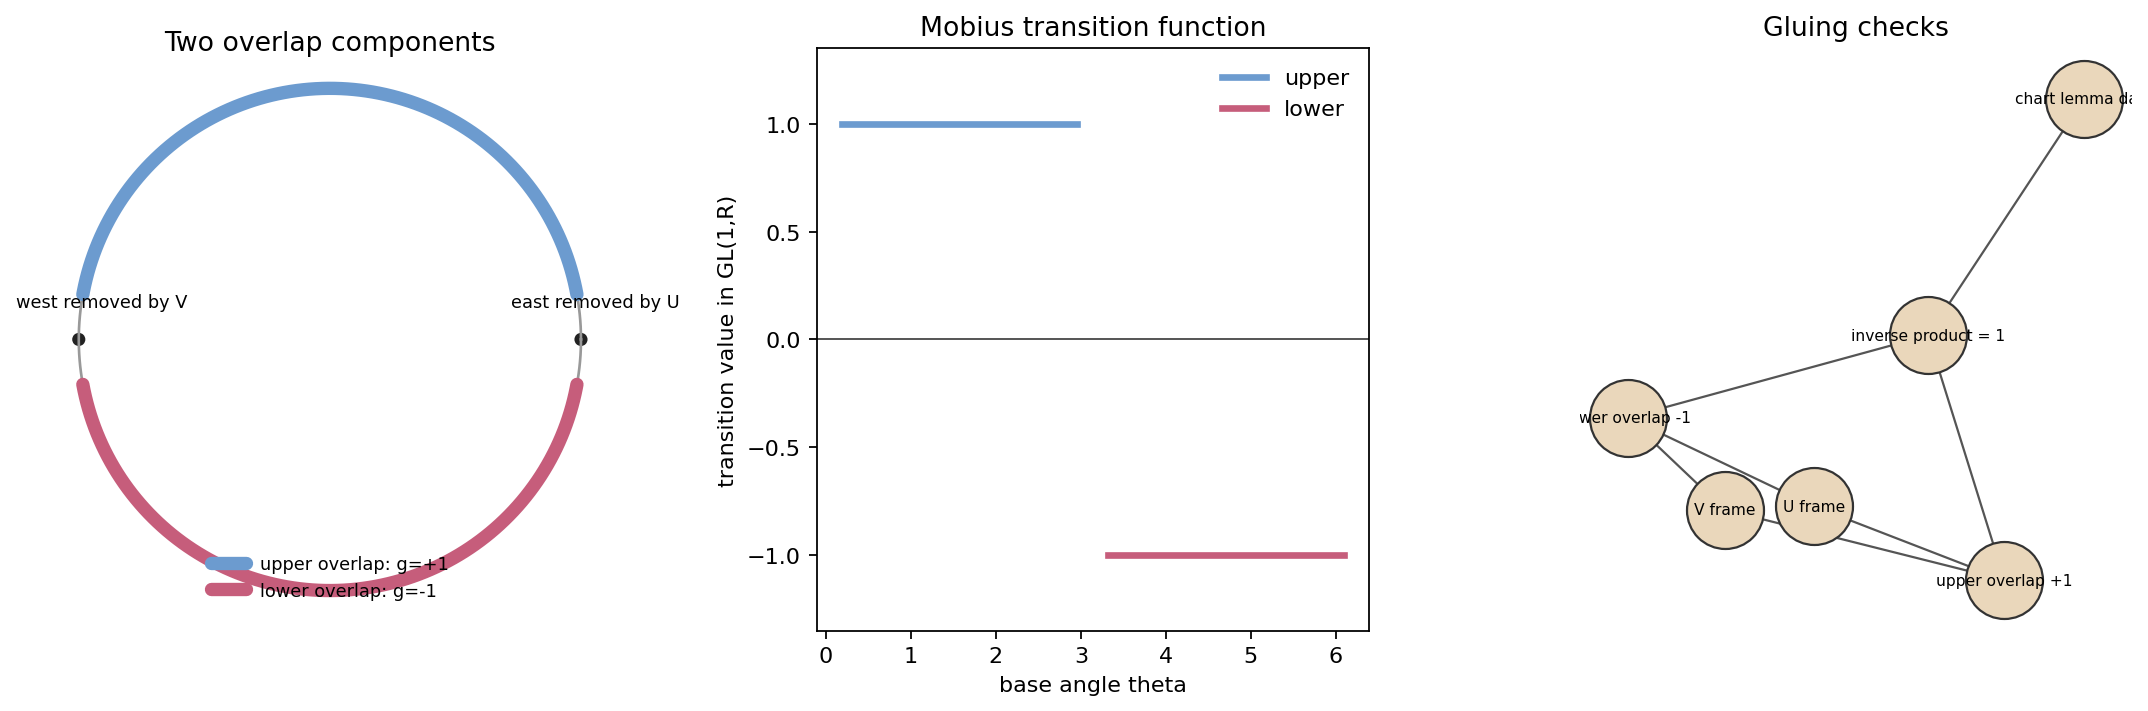

In [4]:
upper_transition = sp.Integer(1)
lower_transition = sp.Integer(-1)
inverse_products = [sp.simplify(upper_transition * upper_transition), sp.simplify(lower_transition * lower_transition)]

fig = plt.figure(figsize=(13.5, 4.6))
ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)

circle_theta = np.linspace(0, 2 * np.pi, 500)
ax0.plot(np.cos(circle_theta), np.sin(circle_theta), color="#999999", linewidth=1.2)
for start, stop, color, label in [
    (0.18, np.pi - 0.18, "#6C9BCF", "upper overlap: g=+1"),
    (np.pi + 0.18, 2 * np.pi - 0.18, "#C65D7B", "lower overlap: g=-1"),
]:
    arc = np.linspace(start, stop, 220)
    ax0.plot(np.cos(arc), np.sin(arc), color=color, linewidth=6, solid_capstyle="round", label=label)
ax0.scatter([1, -1], [0, 0], color=["#222222", "#222222"], s=24)
ax0.text(0.72, 0.13, "east removed by U", fontsize=8)
ax0.text(-1.25, 0.13, "west removed by V", fontsize=8)
ax0.set_aspect("equal")
ax0.set_axis_off()
ax0.legend(loc="lower center", fontsize=8, frameon=False)
ax0.set_title("Two overlap components")

samples = np.linspace(0, 2 * np.pi, 400)
transition_values = np.where((samples > 0.18) & (samples < np.pi - 0.18), 1.0, np.nan)
transition_values_lower = np.where((samples > np.pi + 0.18) & (samples < 2 * np.pi - 0.18), -1.0, np.nan)
ax1.plot(samples, transition_values, color="#6C9BCF", linewidth=3, label="upper")
ax1.plot(samples, transition_values_lower, color="#C65D7B", linewidth=3, label="lower")
ax1.axhline(0, color="#444444", linewidth=0.8)
ax1.set_ylim(-1.35, 1.35)
ax1.set_xlabel("base angle theta")
ax1.set_ylabel("transition value in GL(1,R)")
ax1.set_title("Mobius transition function")
ax1.legend(frameon=False)

overlap_graph = nx.DiGraph()
overlap_graph.add_edges_from([
    ("U frame", "upper overlap +1"),
    ("V frame", "upper overlap +1"),
    ("U frame", "lower overlap -1"),
    ("V frame", "lower overlap -1"),
    ("upper overlap +1", "inverse product = 1"),
    ("lower overlap -1", "inverse product = 1"),
    ("inverse product = 1", "chart lemma data"),
])
pos_overlap = nx.spring_layout(overlap_graph, seed=14, k=0.9)
nx.draw_networkx_edges(overlap_graph, pos_overlap, ax=ax2, arrows=True, arrowstyle="-|>", width=1.0, edge_color="#555555")
nx.draw_networkx_nodes(overlap_graph, pos_overlap, ax=ax2, node_color="#ead7bb", edgecolors="#333333", node_size=1200)
nx.draw_networkx_labels(overlap_graph, pos_overlap, ax=ax2, font_size=7)
ax2.set_title("Gluing checks")
ax2.axis("off")

fig.tight_layout()
transition_path = save_matplotlib(fig, FIGURES / "transition-functions-mobius-cocycle.png")
plt.close(fig)

transition_check = {
    "upper_transition": int(upper_transition),
    "lower_transition": int(lower_transition),
    "inverse_products": [int(value) for value in inverse_products],
    "values_are_in_GL1R": bool(upper_transition != 0 and lower_transition != 0),
    "sign_change_between_overlap_components": bool(upper_transition != lower_transition),
    "chart_lemma_overlap_form": "(p, v) -> (p, g_UV(p) v)",
}
transition_check_path = save_json(transition_check, CHECKS / "transition-functions-mobius-cocycle.json")
generated_artifacts.extend([transition_path, transition_check_path])
display_artifact(transition_path, width=930)


## Sections and Frames: A Global Frame Is a Global Trivialization

A section chooses one vector in every fiber. In a rank-one bundle, a nowhere-zero section is already a global frame, so it is equivalent to a global trivialization. This makes the Mobius line bundle a clean failure mode: if a section is represented on the covering interval by a continuous function `s(theta)` with the endpoint rule `s(2*pi)=-s(0)`, the intermediate value theorem forces a zero.

The plot below compares a nonzero product-bundle section with a Mobius section satisfying the sign-flip endpoint rule.


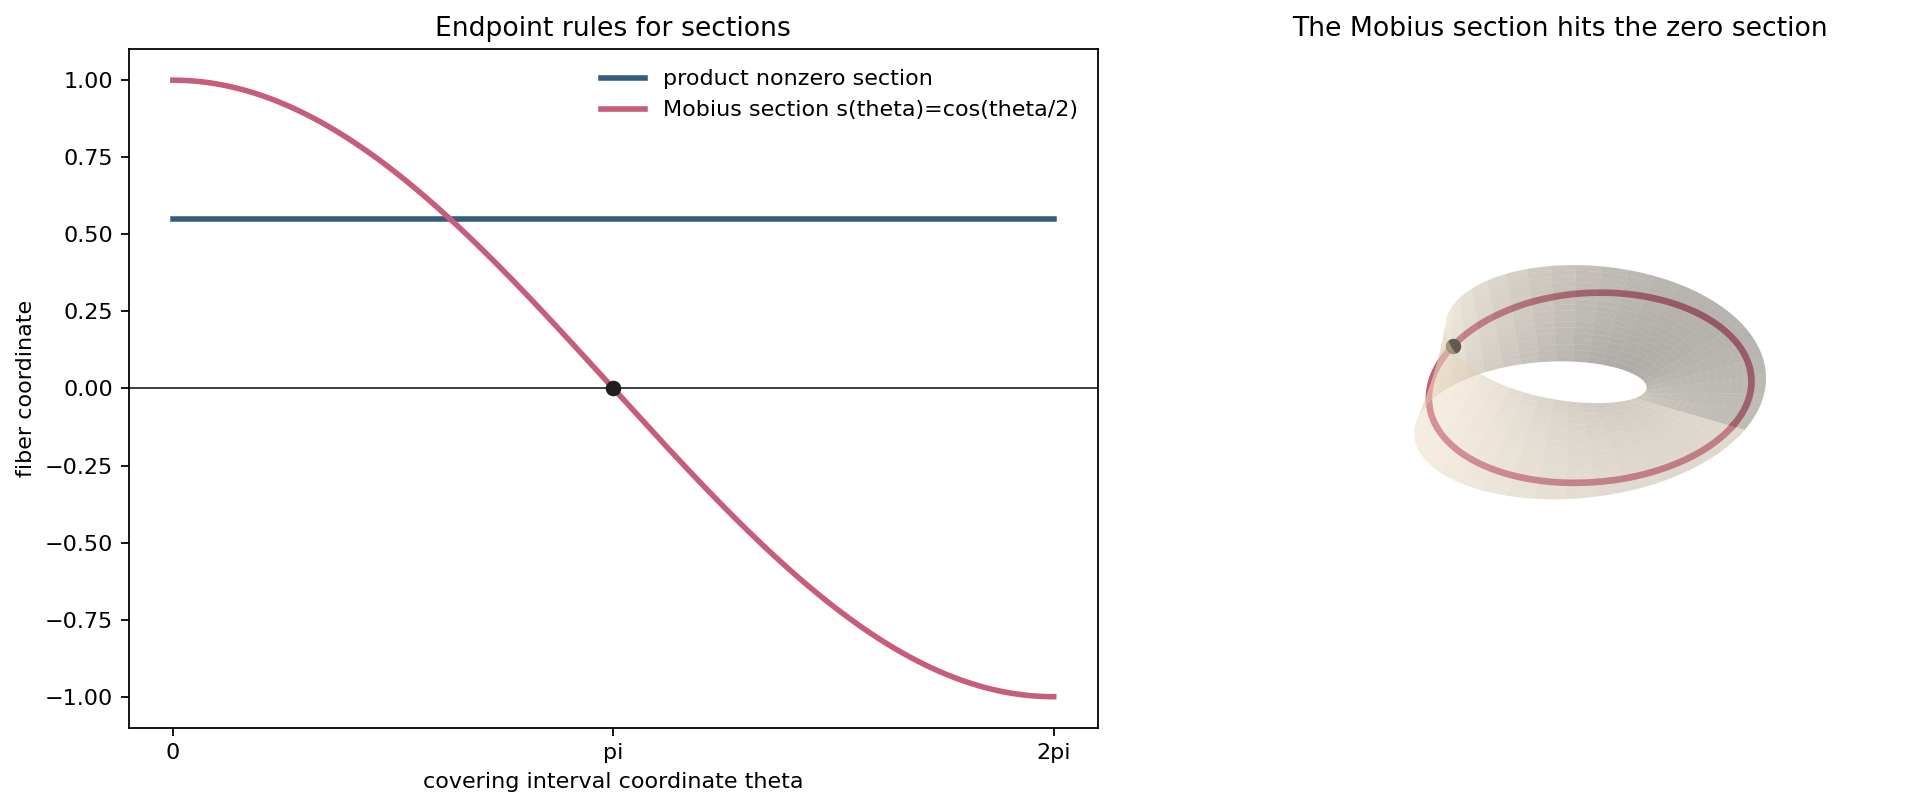

In [5]:
theta_section = np.linspace(0, 2 * np.pi, 600)
product_section = np.ones_like(theta_section) * 0.55
mobius_section = np.cos(theta_section / 2)
zero_angle = np.pi

fig = plt.figure(figsize=(13, 5.2))
ax0 = fig.add_subplot(1, 2, 1)
ax0.plot(theta_section, product_section, color="#355c7d", linewidth=2.5, label="product nonzero section")
ax0.plot(theta_section, mobius_section, color="#c65d7b", linewidth=2.5, label="Mobius section s(theta)=cos(theta/2)")
ax0.scatter([zero_angle], [0], color="#1f1f1f", zorder=4)
ax0.axhline(0, color="#444444", linewidth=0.9)
ax0.set_xticks([0, np.pi, 2 * np.pi], ["0", "pi", "2pi"])
ax0.set_xlabel("covering interval coordinate theta")
ax0.set_ylabel("fiber coordinate")
ax0.set_title("Endpoint rules for sections")
ax0.legend(frameon=False)

ax1 = fig.add_subplot(1, 2, 2, projection="3d")
T2, S2 = np.meshgrid(np.linspace(0, 2 * np.pi, 160), np.linspace(-0.45, 0.45, 18))
band_x = (1 + S2 * np.cos(T2 / 2)) * np.cos(T2)
band_y = (1 + S2 * np.cos(T2 / 2)) * np.sin(T2)
band_z = S2 * np.sin(T2 / 2)
ax1.plot_surface(band_x, band_y, band_z, color="#ead7bb", alpha=0.45, linewidth=0)
section_x = (1 + 0.35 * mobius_section * np.cos(theta_section / 2)) * np.cos(theta_section)
section_y = (1 + 0.35 * mobius_section * np.cos(theta_section / 2)) * np.sin(theta_section)
section_z = 0.35 * mobius_section * np.sin(theta_section / 2)
ax1.plot(section_x, section_y, section_z, color="#c65d7b", linewidth=3)
ax1.scatter([math.cos(zero_angle)], [math.sin(zero_angle)], [0], color="#111111", s=35, label="forced zero")
ax1.set_title("The Mobius section hits the zero section")
ax1.set_axis_off()
set_3d_equal(ax1, 1.6)
fig.tight_layout()

section_path = save_matplotlib(fig, FIGURES / "sections-global-frame-obstruction.png")
plt.close(fig)

section_check = {
    "product_section_min_abs": float(np.min(np.abs(product_section))),
    "mobius_endpoint_sum_s0_plus_s2pi": float(mobius_section[0] + mobius_section[-1]),
    "mobius_min_abs_sampled": float(np.min(np.abs(mobius_section))),
    "mobius_zero_angle": float(zero_angle),
    "nonzero_product_section_is_global_frame_rank1": True,
    "mobius_endpoint_rule_forces_a_zero": bool(abs(mobius_section[0] + mobius_section[-1]) < 1e-12 and np.min(np.abs(mobius_section)) < 1e-2),
}
section_check_path = save_json(section_check, CHECKS / "sections-global-frame-obstruction.json")
generated_artifacts.extend([section_path, section_check_path])
display_artifact(section_path, width=920)


## Local Frames and Tangent/Cotangent-Style Examples

The tangent bundle is the chapter's main example. A coordinate chart on a manifold gives a local frame for the tangent bundle; the frame gives the local trivialization by recording the vector's components. The cotangent bundle, previewed here as the dual bundle pattern, reverses the viewpoint: a covector is a linear test on a tangent fiber.

On the sphere patch below, the coordinate tangent vectors span the tangent plane. The dual coframe is checked by a pairing matrix: rows are covectors, columns are tangent vectors, and the result should be the identity.


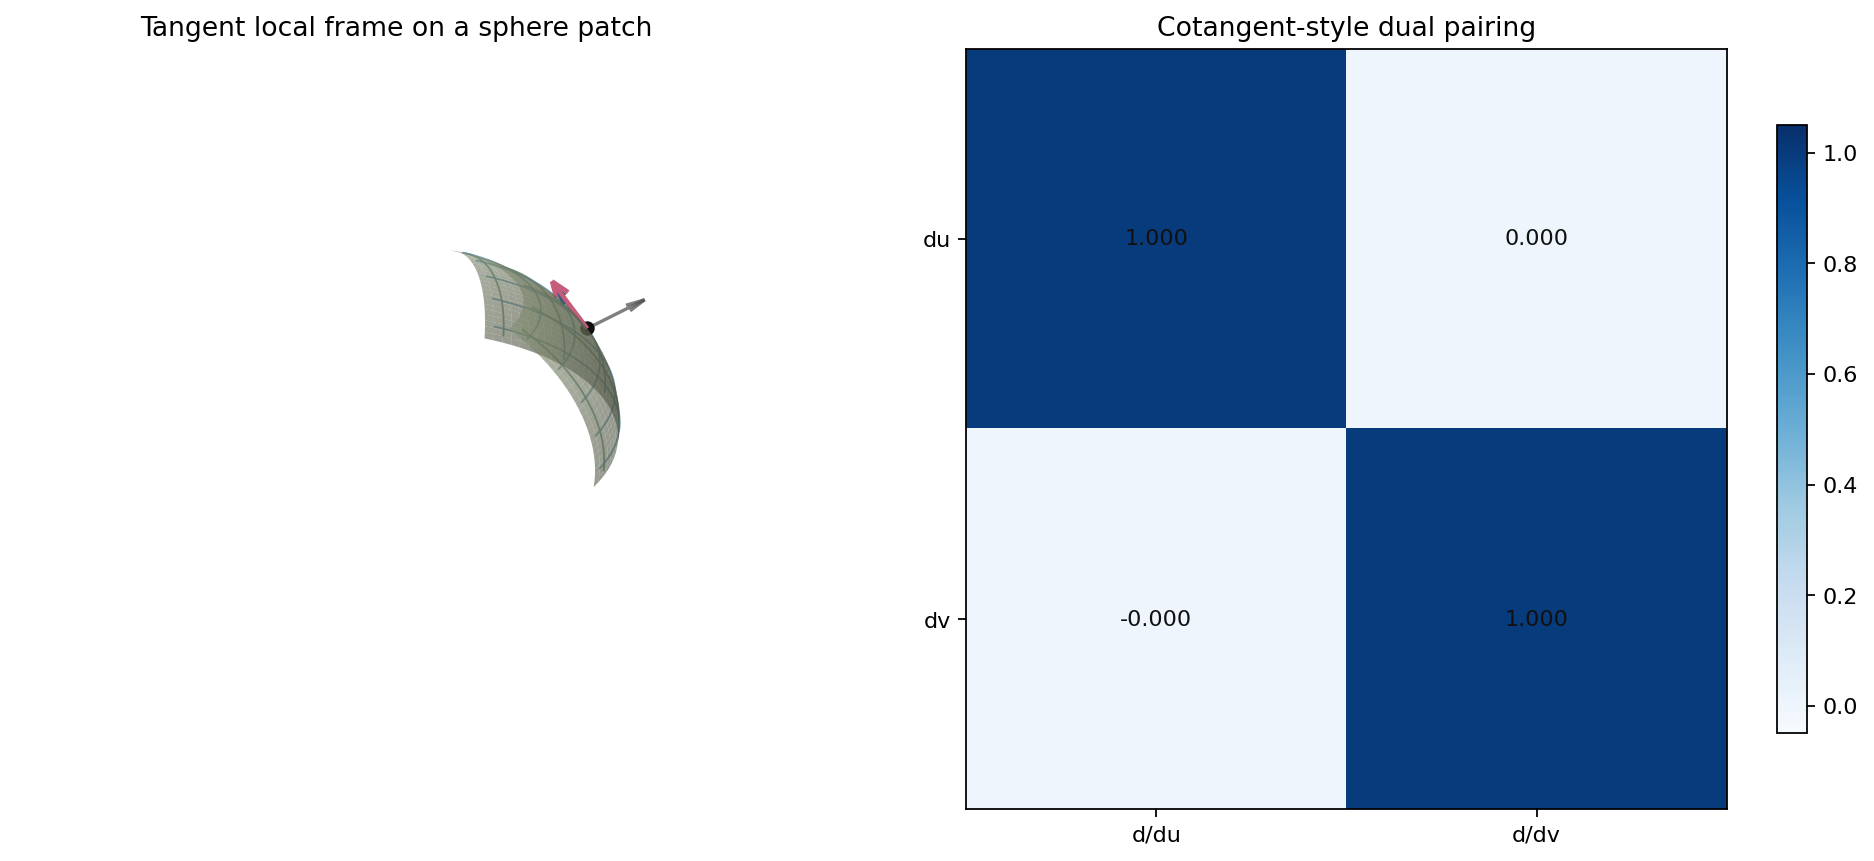

In [6]:
def sphere(u, v):
    u_arr, v_arr = np.broadcast_arrays(np.asarray(u), np.asarray(v))
    return np.array([np.cos(u_arr) * np.cos(v_arr), np.sin(u_arr) * np.cos(v_arr), np.sin(v_arr)])

def sphere_u(u, v):
    u_arr, v_arr = np.broadcast_arrays(np.asarray(u), np.asarray(v))
    return np.array([-np.sin(u_arr) * np.cos(v_arr), np.cos(u_arr) * np.cos(v_arr), np.zeros_like(u_arr)])

def sphere_v(u, v):
    u_arr, v_arr = np.broadcast_arrays(np.asarray(u), np.asarray(v))
    return np.array([-np.cos(u_arr) * np.sin(v_arr), -np.sin(u_arr) * np.sin(v_arr), np.cos(v_arr)])

u0 = 0.85
v0 = 0.45
U_grid, V_grid = np.meshgrid(np.linspace(u0 - 0.85, u0 + 0.85, 36), np.linspace(v0 - 0.55, v0 + 0.55, 26))
P = sphere(U_grid, V_grid)
p0 = sphere(u0, v0)
Xu = sphere_u(u0, v0)
Xv = sphere_v(u0, v0)
normal = p0 / np.linalg.norm(p0)
dual_u = Xu / np.dot(Xu, Xu)
dual_v = Xv / np.dot(Xv, Xv)
pairing = np.array([
    [np.dot(dual_u, Xu), np.dot(dual_u, Xv)],
    [np.dot(dual_v, Xu), np.dot(dual_v, Xv)],
])
metric = np.array([
    [np.dot(Xu, Xu), np.dot(Xu, Xv)],
    [np.dot(Xv, Xu), np.dot(Xv, Xv)],
])

fig = plt.figure(figsize=(13, 5.3))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax0.plot_surface(P[0], P[1], P[2], color="#d7e9b9", alpha=0.62, linewidth=0)
for uu in np.linspace(u0 - 0.75, u0 + 0.75, 5):
    vv = np.linspace(v0 - 0.5, v0 + 0.5, 100)
    curve = sphere(uu, vv)
    ax0.plot(curve[0], curve[1], curve[2], color="#61876E", linewidth=0.8, alpha=0.8)
for vv in np.linspace(v0 - 0.45, v0 + 0.45, 5):
    uu = np.linspace(u0 - 0.8, u0 + 0.8, 100)
    curve = sphere(uu, vv)
    ax0.plot(curve[0], curve[1], curve[2], color="#6096B4", linewidth=0.8, alpha=0.8)
arrow_scale = 0.42
ax0.quiver(*p0, *Xu, length=arrow_scale, normalize=True, color="#355c7d", linewidth=2, label="d/du")
ax0.quiver(*p0, *Xv, length=arrow_scale, normalize=True, color="#c65d7b", linewidth=2, label="d/dv")
ax0.quiver(*p0, *normal, length=0.32, normalize=True, color="#555555", linewidth=1.5, alpha=0.75, label="normal")
ax0.scatter([p0[0]], [p0[1]], [p0[2]], color="#111111", s=30)
ax0.set_title("Tangent local frame on a sphere patch")
ax0.set_axis_off()
set_3d_equal(ax0, 1.15)

ax1 = fig.add_subplot(1, 2, 2)
image = ax1.imshow(pairing, vmin=-0.05, vmax=1.05, cmap="Blues")
ax1.set_xticks([0, 1], ["d/du", "d/dv"])
ax1.set_yticks([0, 1], ["du", "dv"])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{pairing[i, j]:.3f}", ha="center", va="center", color="#111111")
ax1.set_title("Cotangent-style dual pairing")
fig.colorbar(image, ax=ax1, shrink=0.8)
fig.tight_layout()

tangent_cotangent_path = save_matplotlib(fig, FIGURES / "tangent-cotangent-local-frame.png")
plt.close(fig)

tangent_cotangent_check = {
    "metric_matrix": metric.round(12).tolist(),
    "dual_pairing_matrix": pairing.round(12).tolist(),
    "dual_pairing_identity_error": float(np.max(np.abs(pairing - np.eye(2)))),
    "tangent_vectors_orthogonal_to_normal": bool(abs(np.dot(Xu, normal)) < 1e-12 and abs(np.dot(Xv, normal)) < 1e-12),
    "metric_determinant_positive": bool(np.linalg.det(metric) > 0),
}
tangent_cotangent_check_path = save_json(tangent_cotangent_check, CHECKS / "tangent-cotangent-local-frame.json")
generated_artifacts.extend([tangent_cotangent_path, tangent_cotangent_check_path])
display_artifact(tangent_cotangent_path, width=920)


## Bundle Homomorphisms: Pointwise Maps, Constant Rank, and a Warning

A bundle homomorphism over the same base acts fiber by fiber. In a local trivialization this looks like a smoothly varying matrix. If the rank of that matrix is constant, its kernel and image are stable candidates for subbundles. If rank jumps, the fiber dimension of the kernel or image jumps, so the subbundle condition fails.

The characterization lemma also says that a bundle homomorphism is exactly a `C^infty(M)`-linear operation on sections. Multiplication by a smooth function is pointwise and passes this test. Differentiation of sections does not.


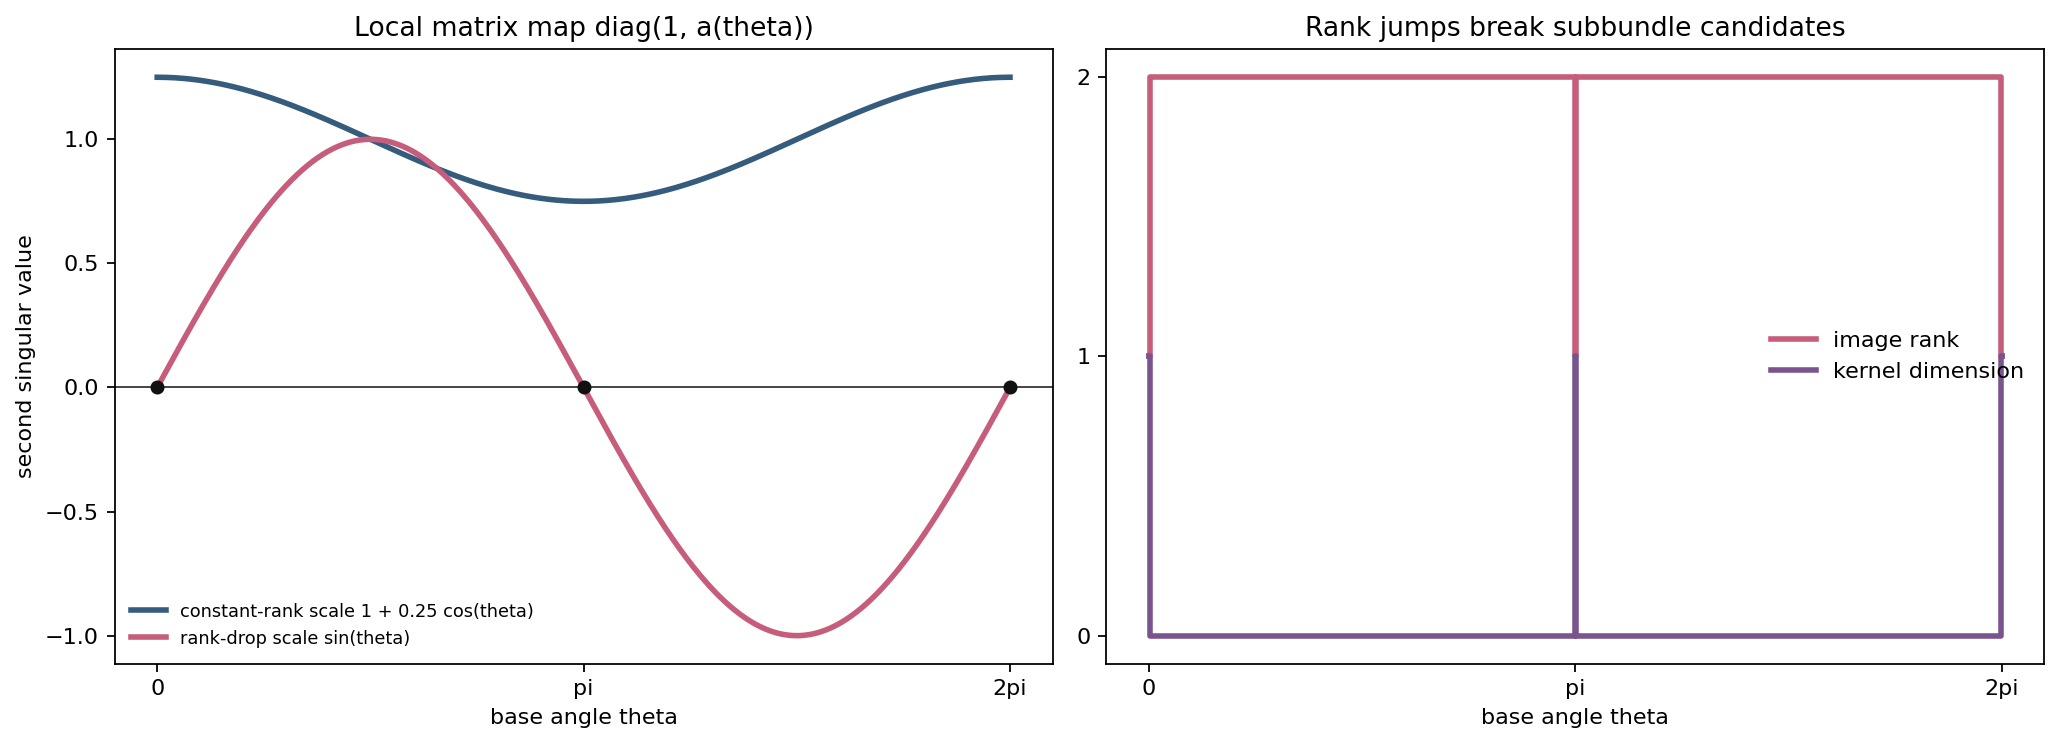

Derivative residual showing non-pointwise behavior: 2*x*(x + 2)


In [7]:
theta_rank = np.linspace(0, 2 * np.pi, 501)
good_scale = 1.0 + 0.25 * np.cos(theta_rank)
bad_scale = np.sin(theta_rank)
good_rank = np.where(np.abs(good_scale) > 1e-10, 2, 1)
bad_rank = np.where(np.abs(bad_scale) > 1e-8, 2, 1)
kernel_dim_bad = 2 - bad_rank

x = sp.symbols("x", real=True)
f = x**2 + 1
section = x + 2
multiplier = sp.sin(x) + 3
multiplication_residual = sp.simplify(multiplier * (f * section) - f * (multiplier * section))
derivative_residual = sp.simplify(sp.diff(f * section, x) - f * sp.diff(section, x))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.8))
ax0.plot(theta_rank, good_scale, color="#355c7d", linewidth=2.5, label="constant-rank scale 1 + 0.25 cos(theta)")
ax0.plot(theta_rank, bad_scale, color="#c65d7b", linewidth=2.5, label="rank-drop scale sin(theta)")
ax0.axhline(0, color="#333333", linewidth=0.8)
ax0.scatter([0, np.pi, 2 * np.pi], [0, 0, 0], color="#111111", s=28, zorder=3)
ax0.set_xticks([0, np.pi, 2 * np.pi], ["0", "pi", "2pi"])
ax0.set_xlabel("base angle theta")
ax0.set_ylabel("second singular value")
ax0.set_title("Local matrix map diag(1, a(theta))")
ax0.legend(frameon=False, fontsize=8)

ax1.step(theta_rank, bad_rank, where="mid", color="#c65d7b", linewidth=2.5, label="image rank")
ax1.step(theta_rank, kernel_dim_bad, where="mid", color="#7A548C", linewidth=2.5, label="kernel dimension")
ax1.set_yticks([0, 1, 2])
ax1.set_xticks([0, np.pi, 2 * np.pi], ["0", "pi", "2pi"])
ax1.set_xlabel("base angle theta")
ax1.set_title("Rank jumps break subbundle candidates")
ax1.legend(frameon=False)
fig.tight_layout()

homomorphism_path = save_matplotlib(fig, FIGURES / "bundle-homomorphism-rank-tracker.png")
plt.close(fig)

homomorphism_check = {
    "constant_rank_values": sorted(set(int(v) for v in good_rank)),
    "rank_drop_values": sorted(set(int(v) for v in bad_rank)),
    "kernel_dimensions_for_rank_drop": sorted(set(int(v) for v in kernel_dim_bad)),
    "multiplication_Cinfty_linearity_residual": str(multiplication_residual),
    "derivative_Cinfty_linearity_residual": str(derivative_residual),
    "multiplication_is_bundle_homomorphism_test": bool(multiplication_residual == 0),
    "derivative_fails_bundle_homomorphism_test": bool(derivative_residual != 0),
}
homomorphism_check_path = save_json(homomorphism_check, CHECKS / "bundle-homomorphism-rank-tracker.json")
generated_artifacts.extend([homomorphism_path, homomorphism_check_path])
display_artifact(homomorphism_path, width=920)
print("Derivative residual showing non-pointwise behavior:", derivative_residual)


## Subbundles: Local Frames Certify Constant Fiber Dimension

A subbundle is more than a subset made from subspaces. The subspaces must assemble smoothly and keep the same dimension. The local frame criterion gives a practical test: near every base point, can you find smooth sections that form a basis for the proposed subspaces?

The tangent and normal lines along the unit circle pass the test. The radial line field in the plane, generated by `(x,y)`, is a useful failure mode: it is one-dimensional away from the origin but drops to the zero subspace at the origin.


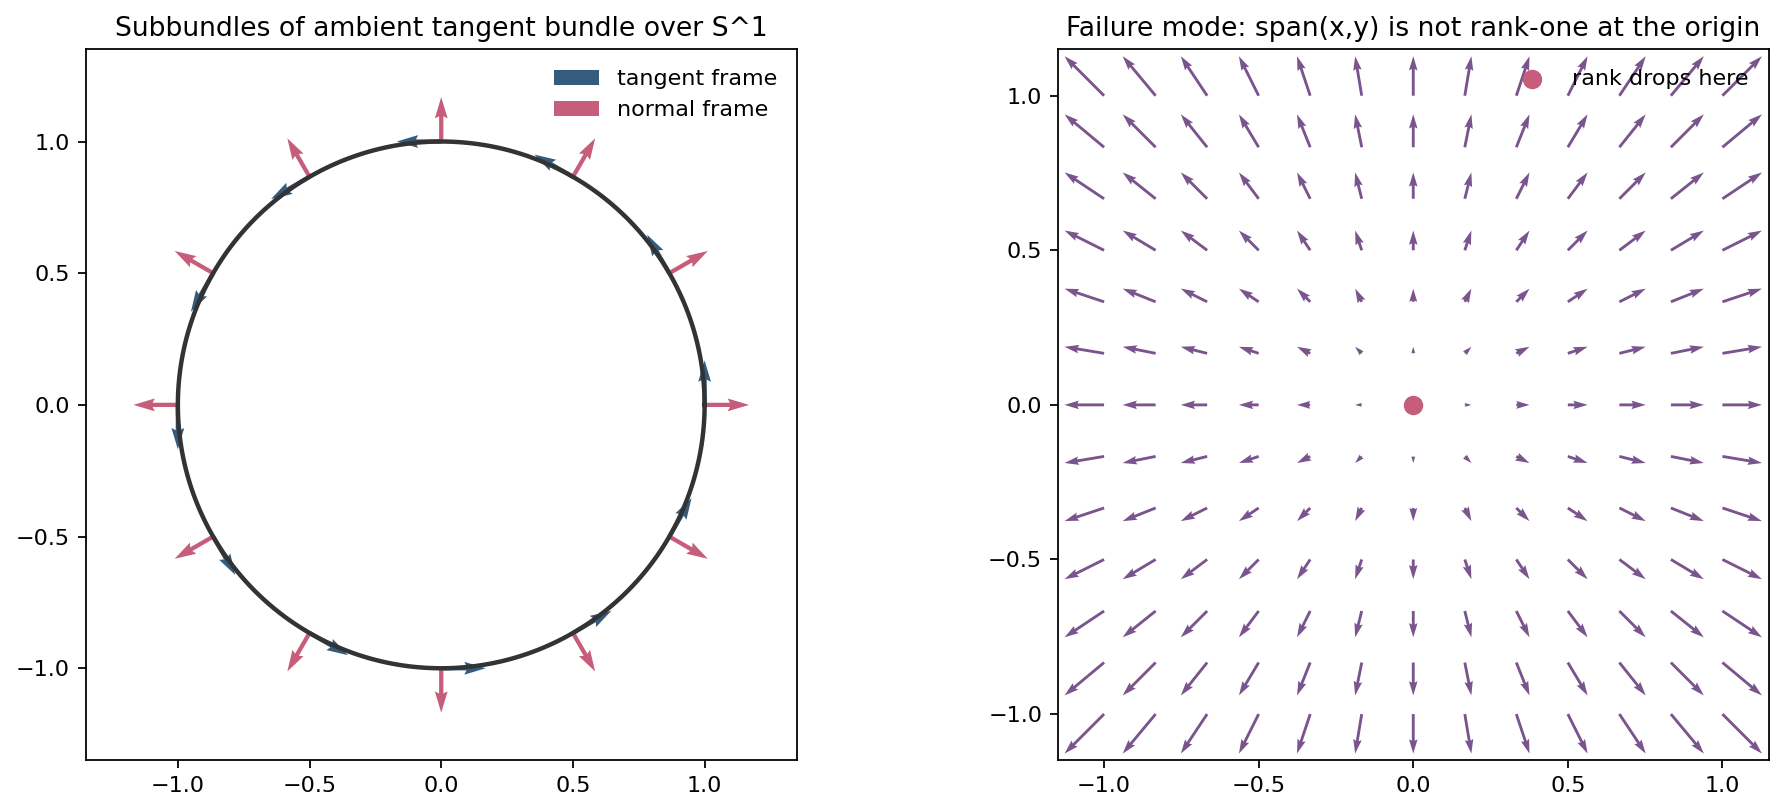

In [8]:
circle_angles = np.linspace(0, 2 * np.pi, 300)
circle = np.column_stack([np.cos(circle_angles), np.sin(circle_angles)])
sample_angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)
sample_points = np.column_stack([np.cos(sample_angles), np.sin(sample_angles)])
tangents = np.column_stack([-np.sin(sample_angles), np.cos(sample_angles)])
normals = sample_points.copy()
dot_products = np.sum(tangents * normals, axis=1)
tangent_norms = np.linalg.norm(tangents, axis=1)
normal_norms = np.linalg.norm(normals, axis=1)

grid_vals = np.linspace(-1, 1, 13)
X_grid, Y_grid = np.meshgrid(grid_vals, grid_vals)
U_radial = X_grid
V_radial = Y_grid
radial_norm = np.sqrt(U_radial**2 + V_radial**2)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12.5, 5.2))
ax0.plot(circle[:, 0], circle[:, 1], color="#333333", linewidth=2)
ax0.quiver(sample_points[:, 0], sample_points[:, 1], tangents[:, 0], tangents[:, 1], color="#355c7d", scale=16, width=0.006, label="tangent frame")
ax0.quiver(sample_points[:, 0], sample_points[:, 1], normals[:, 0], normals[:, 1], color="#c65d7b", scale=16, width=0.006, label="normal frame")
ax0.set_aspect("equal")
ax0.set_title("Subbundles of ambient tangent bundle over S^1")
ax0.legend(frameon=False, loc="upper right")
ax0.set_xlim(-1.35, 1.35)
ax0.set_ylim(-1.35, 1.35)

mask = radial_norm > 1e-12
ax1.quiver(X_grid[mask], Y_grid[mask], U_radial[mask], V_radial[mask], color="#7A548C", scale=18, width=0.004)
ax1.scatter([0], [0], color="#c65d7b", s=60, label="rank drops here")
ax1.set_aspect("equal")
ax1.set_title("Failure mode: span(x,y) is not rank-one at the origin")
ax1.set_xlim(-1.15, 1.15)
ax1.set_ylim(-1.15, 1.15)
ax1.legend(frameon=False)
fig.tight_layout()

subbundle_path = save_matplotlib(fig, FIGURES / "subbundle-normal-rank-test.png")
plt.close(fig)

subbundle_check = {
    "max_abs_tangent_normal_dot": float(np.max(np.abs(dot_products))),
    "tangent_norm_min": float(np.min(tangent_norms)),
    "normal_norm_min": float(np.min(normal_norms)),
    "circle_tangent_and_normal_are_smooth_rank_one_subbundles": bool(np.max(np.abs(dot_products)) < 1e-12),
    "radial_generator_min_norm": float(np.min(radial_norm)),
    "radial_span_has_rank_drop_at_origin": bool(np.min(radial_norm) == 0.0),
}
subbundle_check_path = save_json(subbundle_check, CHECKS / "subbundle-normal-rank-test.json")
generated_artifacts.extend([subbundle_path, subbundle_check_path])
display_artifact(subbundle_path, width=900)


## Fiber Bundles: Local Product Without Linear Fibers

A vector bundle is automatically a fiber bundle with model fiber `R^k`, but the converse is false. Fiber bundles keep the local product diagram and drop the demand that fibers are vector spaces with linear transition maps.

The two-sheet covering of a circle has a discrete two-point model fiber. The Mobius band restricted to interval fibers has model fiber `[-1,1]`; it is locally a product, but `[-1,1]` is not a vector space because addition is not closed.


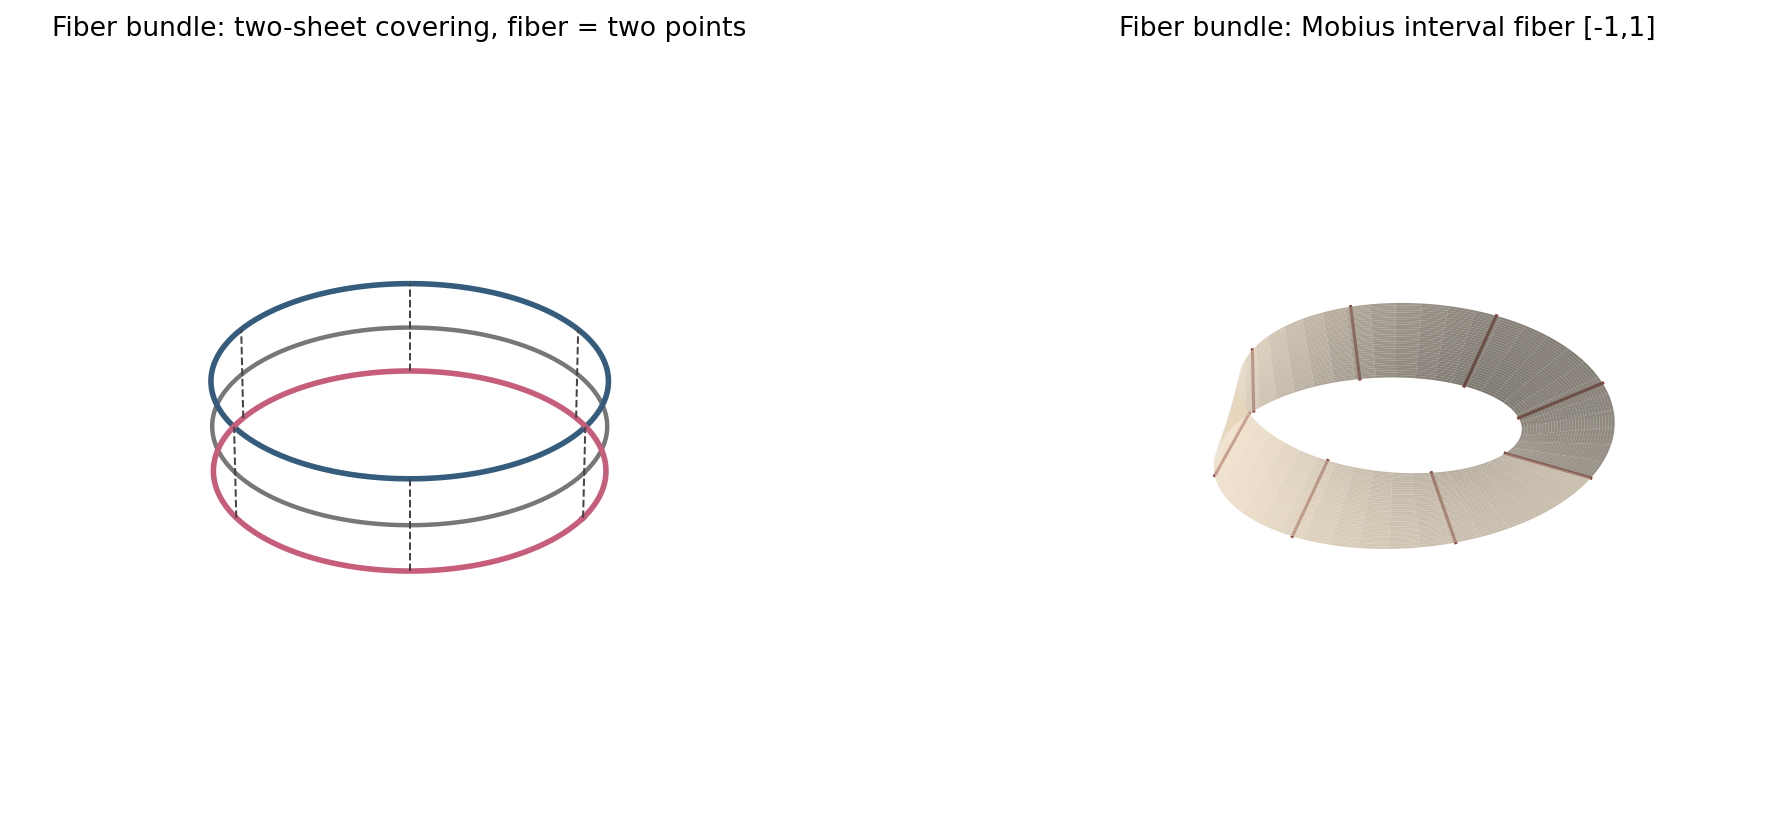

In [9]:
cover_theta = np.linspace(0, 2 * np.pi, 400)
base_x = np.cos(cover_theta)
base_y = np.sin(cover_theta)
sheet_height = 0.35

fig = plt.figure(figsize=(13, 5.3))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax0.plot(base_x, base_y, np.zeros_like(cover_theta), color="#777777", linewidth=2, label="base S^1")
ax0.plot(base_x, base_y, sheet_height * np.ones_like(cover_theta), color="#355c7d", linewidth=2.5, label="sheet 1")
ax0.plot(base_x, base_y, -sheet_height * np.ones_like(cover_theta), color="#c65d7b", linewidth=2.5, label="sheet 2")
for angle in np.linspace(0, 2 * np.pi, 6, endpoint=False):
    ax0.plot([np.cos(angle), np.cos(angle)], [np.sin(angle), np.sin(angle)], [-sheet_height, sheet_height], color="#444444", linestyle="--", linewidth=0.9)
ax0.set_title("Fiber bundle: two-sheet covering, fiber = two points")
ax0.set_axis_off()
set_3d_equal(ax0, 1.25)

ax1 = fig.add_subplot(1, 2, 2, projection="3d")
T3, S3 = np.meshgrid(np.linspace(0, 2 * np.pi, 180), np.linspace(-1, 1, 32))
mob_int_x = (1 + 0.28 * S3 * np.cos(T3 / 2)) * np.cos(T3)
mob_int_y = (1 + 0.28 * S3 * np.cos(T3 / 2)) * np.sin(T3)
mob_int_z = 0.28 * S3 * np.sin(T3 / 2)
ax1.plot_surface(mob_int_x, mob_int_y, mob_int_z, color="#ead7bb", alpha=0.75, linewidth=0)
for fiber_angle in np.linspace(0, 2 * np.pi, 8, endpoint=False):
    fiber = np.linspace(-1, 1, 20)
    direction = mobius_direction(fiber_angle)
    base = np.array([np.cos(fiber_angle), np.sin(fiber_angle), 0.0])
    pts = base[:, None] + 0.28 * direction[:, None] * fiber[None, :]
    ax1.plot(pts[0], pts[1], pts[2], color="#8b3a3a", linewidth=1.4)
ax1.set_title("Fiber bundle: Mobius interval fiber [-1,1]")
ax1.set_axis_off()
set_3d_equal(ax1, 1.45)
fig.tight_layout()

fiber_bundle_path = save_matplotlib(fig, FIGURES / "fiber-bundle-models.png")
plt.close(fig)

covering_sample_angles = np.linspace(0, 2 * np.pi, 6, endpoint=False)
preimage_counts = [2 for _ in covering_sample_angles]
interval_addition_counterexample = 0.8 + 0.8
fiber_bundle_check = {
    "covering_preimage_counts_sampled": preimage_counts,
    "covering_has_constant_discrete_fiber_size": bool(len(set(preimage_counts)) == 1 and preimage_counts[0] == 2),
    "interval_fiber_model": "[-1,1]",
    "interval_addition_counterexample_0p8_plus_0p8": interval_addition_counterexample,
    "interval_closed_under_addition": bool(-1 <= interval_addition_counterexample <= 1),
    "mobius_interval_is_not_a_vector_bundle_reason": "the model fiber [-1,1] is not closed under vector addition",
}
fiber_bundle_check_path = save_json(fiber_bundle_check, CHECKS / "fiber-bundle-models.json")
generated_artifacts.extend([fiber_bundle_path, fiber_bundle_check_path])
display_artifact(fiber_bundle_path, width=920)


## Applied Lab: Toggle the Twist

The fastest experiment is to change the endpoint multiplier for a rank-one bundle over the circle.

- multiplier `+1`: a constant nonzero section descends, so the line bundle can have a global frame.
- multiplier `-1`: a continuous section represented on `[0,2*pi]` must satisfy `s(2*pi)=-s(0)`, so it has a zero.

This is not a classification theorem for all bundles. It is a small lab that trains the key habit: translate gluing data into a visible section or frame test.


In [10]:
twist_lab_rows = []
for name, endpoint_multiplier in [("product line bundle", 1), ("Mobius line bundle", -1)]:
    if endpoint_multiplier == 1:
        possible_nonzero_constant_section = True
        forced_zero_by_endpoint_rule = False
        sample_section = "s(theta)=1"
    else:
        possible_nonzero_constant_section = False
        forced_zero_by_endpoint_rule = True
        sample_section = "s(theta)=cos(theta/2), zero at theta=pi"
    twist_lab_rows.append({
        "bundle": name,
        "endpoint_multiplier": endpoint_multiplier,
        "sample_section": sample_section,
        "nonzero_constant_section_descends": possible_nonzero_constant_section,
        "endpoint_rule_forces_zero": forced_zero_by_endpoint_rule,
    })

twist_lab_path = save_csv(twist_lab_rows, TABLES / "applied-lab-twist-toggle.csv")
twist_lab_check_path = save_json(
    {
        "lab_question": "What changes when the endpoint multiplier is toggled?",
        "rows": twist_lab_rows,
        "product_has_nonzero_global_frame_in_rank1": twist_lab_rows[0]["nonzero_constant_section_descends"],
        "mobius_has_forced_zero_for_every_continuous_section_in_this_model": twist_lab_rows[1]["endpoint_rule_forces_zero"],
    },
    CHECKS / "applied-lab-twist-toggle.json",
)
generated_artifacts.extend([twist_lab_path, twist_lab_check_path])
print(f"Applied lab table: {rel(twist_lab_path)}")
print(json.dumps(twist_lab_rows, indent=2))


Applied lab table: artifacts/chapter-10-vector-bundles/tables/applied-lab-twist-toggle.csv
[
  {
    "bundle": "product line bundle",
    "endpoint_multiplier": 1,
    "sample_section": "s(theta)=1",
    "nonzero_constant_section_descends": true,
    "endpoint_rule_forces_zero": false
  },
  {
    "bundle": "Mobius line bundle",
    "endpoint_multiplier": -1,
    "sample_section": "s(theta)=cos(theta/2), zero at theta=pi",
    "nonzero_constant_section_descends": false,
    "endpoint_rule_forces_zero": true
  }
]


## Computational Checks

The notebook's checks are deliberately local and inspectable. They do not replace proofs; they make the proof hypotheses tangible.

- local trivialization check: product orientation returns as `+1`, Mobius orientation returns as `-1`;
- transition check: overlap values stay inside `GL(1,R)` and inverse products are `1`;
- section check: the Mobius endpoint rule forces a zero;
- frame/coframe check: the cotangent-style pairing matrix is identity;
- homomorphism check: pointwise multiplication is `C^infty`-linear, differentiation is not;
- subbundle check: valid tangent/normal frames have constant rank, while the radial generator vanishes;
- fiber-bundle check: local product data can have non-vector model fibers.


## Takeaways

- A vector bundle is locally a product but globally controlled by transition functions.
- A local frame and a local trivialization are two languages for the same data.
- In rank one, a nowhere-zero global section is already a global frame, so the Mobius line bundle's forced zero is a visible obstruction to triviality.
- Bundle homomorphisms act pointwise on fibers; `C^infty(M)`-linearity is the section-level test for this pointwise behavior.
- Subbundles require constant fiber dimension and smooth local frames; rank jumps are the main failure mode.
- Fiber bundles keep the local-product diagram but do not require vector-space fibers or linear transition functions.


In [11]:
final_sanity = {
    "unit": UNIT_TITLE,
    "source_span": {
        "printed_pages": "249-271",
        "pdf_physical_pages_inspected": "267-289",
        "source_map_focus": source_inventory["source_map_focus"],
    },
    "concepts_covered": source_inventory["concepts"],
    "artifacts": [rel(path) for path in generated_artifacts],
    "checks": {
        "concept_graph_connected": bool(nx.is_weakly_connected(concept_graph)),
        "product_orientation_returns_positive": local_product_check["product_returns_with_same_orientation"],
        "mobius_orientation_returns_negative": local_product_check["mobius_returns_with_opposite_orientation"],
        "transition_values_in_GL1R": transition_check["values_are_in_GL1R"],
        "transition_inverse_products_equal_one": transition_check["inverse_products"] == [1, 1],
        "mobius_section_forced_zero": section_check["mobius_endpoint_rule_forces_a_zero"],
        "dual_pairing_identity": tangent_cotangent_check["dual_pairing_identity_error"] < 1e-12,
        "multiplication_is_Cinfty_linear": homomorphism_check["multiplication_is_bundle_homomorphism_test"],
        "derivative_is_not_bundle_homomorphism": homomorphism_check["derivative_fails_bundle_homomorphism_test"],
        "rank_drop_detected": homomorphism_check["rank_drop_values"] == [1, 2],
        "circle_subbundle_frame_valid": subbundle_check["circle_tangent_and_normal_are_smooth_rank_one_subbundles"],
        "radial_rank_failure_detected": subbundle_check["radial_span_has_rank_drop_at_origin"],
        "covering_has_constant_two_point_fiber": fiber_bundle_check["covering_has_constant_discrete_fiber_size"],
        "interval_fiber_not_vector_space": not fiber_bundle_check["interval_closed_under_addition"],
        "artifact_count_at_least_18": len(generated_artifacts) >= 18,
    },
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
generated_artifacts.append(final_sanity_path)

assert_artifacts(generated_artifacts, min_bytes=80)
failed = [name for name, passed in final_sanity["checks"].items() if not passed]
if failed:
    raise AssertionError(f"Chapter 10 sanity checks failed: {failed}")

display_artifact(final_sanity_path)
print(json.dumps(final_sanity, indent=2))
print(f"final_sanity passed for {UNIT_TITLE} with {len(generated_artifacts)} artifacts")


`final_sanity.json`

{
  "unit": "Vector Bundles",
  "source_span": {
    "printed_pages": "249-271",
    "pdf_physical_pages_inspected": "267-289",
    "source_map_focus": "Vector bundles, sections, bundle homomorphisms, subbundles, and fiber bundles."
  },
  "concepts_covered": [
    "vector bundle",
    "local trivialization",
    "transition function",
    "vector bundle chart lemma",
    "Whitney sum",
    "restricted bundle",
    "section",
    "local/global frame",
    "bundle homomorphism",
    "subbundle",
    "constant-rank kernel/image test",
    "normal bundle",
    "fiber bundle"
  ],
  "artifacts": [
    "artifacts/chapter-10-vector-bundles/tables/chapter10-library-routing.csv",
    "artifacts/chapter-10-vector-bundles/checks/source-span-inventory.json",
    "artifacts/chapter-10-vector-bundles/figures/chapter10-concept-dependency-map.png",
    "artifacts/chapter-10-vector-bundles/checks/chapter10-concept-dependency-map.json",
    "artifacts/chapter-10-vector-bundles/figures/local-products-an